# Exploratory Data Analysis on Retail Sales Data

## Oasis Infobyte – Data Analytics Internship
### Level 1 – Task 1

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on retail sales data to:

- Understand the structure and quality of the dataset.
- Analyze overall sales performance and identify monthly and quarterly sales trends.
- Understand customer demographics based on age groups and gender.
- Identify top-selling products and analyze revenue across product categories.
- Examine relationships between numerical variables using correlation analysis.
- Discover meaningful patterns and insights through data visualization.
- Provide actionable business recommendations based on the findings.

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Desktop\OIBSIP\DataAnalytics_L1_EDARetailSales\Dataset\bike_sales_data_world_2013_2023.csv")

df.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,...,Rating,Shipping_Weight,Delivery_Time,Discount,Eco_Friendly,Shipping_Cost,Shipping_Company,Shipping_Type,Insurance,Return_Policy
0,2017-11-26,26,November,2017,19,Youth (<25),M,Canada,British Columbia,Accessories,...,4,13.25,2,25,True,40.58,GLS,Standard,Basic,30 Days
1,2014-11-26,26,November,2014,19,Youth (<25),M,Canada,British Columbia,Accessories,...,5,4.56,4,1,True,95.32,Posti,Same Day,NaN,30 Days
2,2019-03-23,23,March,2019,49,Adults (35-64),M,Australia,New South Wales,Accessories,...,3,8.97,1,0,True,74.54,GLS,Express,Premium,7 Days
3,2015-03-23,23,March,2015,49,Adults (35-64),M,Australia,New South Wales,Accessories,...,5,2.56,1,10,False,61.87,DHL,Same Day,NaN,7 Days
4,2018-05-15,15,May,2018,47,Adults (35-64),F,Australia,New South Wales,Accessories,...,5,11.21,1,6,False,19.82,GLS,Same Day,Basic,30 Days


## Initial Data Inspection

Before performing data cleaning and analysis, the dataset is inspected to understand its size, structure, data types, and data quality.

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 226072
Number of columns: 33


In [6]:
df.columns.tolist()

['Date',
 'Day',
 'Month',
 'Year',
 'Customer_Age',
 'Age_Group',
 'Customer_Gender',
 'Country',
 'State',
 'Product_Category',
 'Sub_Category',
 'Product',
 'Order_Quantity',
 'Unit_Cost',
 'Unit_Price',
 'Profit',
 'Cost',
 'Revenue',
 'Size',
 'Color',
 'Material',
 'Warranty',
 'Manufacturer',
 'Rating',
 'Shipping_Weight',
 'Delivery_Time',
 'Discount',
 'Eco_Friendly',
 'Shipping_Cost',
 'Shipping_Company',
 'Shipping_Type',
 'Insurance',
 'Return_Policy']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226072 entries, 0 to 226071
Data columns (total 33 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              226072 non-null  object 
 1   Day               226072 non-null  int64  
 2   Month             226072 non-null  object 
 3   Year              226072 non-null  int64  
 4   Customer_Age      226072 non-null  int64  
 5   Age_Group         226072 non-null  object 
 6   Customer_Gender   226072 non-null  object 
 7   Country           226072 non-null  object 
 8   State             226072 non-null  object 
 9   Product_Category  226072 non-null  object 
 10  Sub_Category      226072 non-null  object 
 11  Product           226072 non-null  object 
 12  Order_Quantity    226072 non-null  int64  
 13  Unit_Cost         226072 non-null  int64  
 14  Unit_Price        226072 non-null  int64  
 15  Profit            226072 non-null  int64  
 16  Cost              22

In [8]:
df.isnull().sum()

Date                    0
Day                     0
Month                   0
Year                    0
Customer_Age            0
Age_Group               0
Customer_Gender         0
Country                 0
State                   0
Product_Category        0
Sub_Category            0
Product                 0
Order_Quantity          0
Unit_Cost               0
Unit_Price              0
Profit                  0
Cost                    0
Revenue                 0
Size                    0
Color                   0
Material                0
Warranty                0
Manufacturer            0
Rating                  0
Shipping_Weight         0
Delivery_Time           0
Discount                0
Eco_Friendly            0
Shipping_Cost           0
Shipping_Company        0
Shipping_Type           0
Insurance           75282
Return_Policy           0
dtype: int64

In [9]:
missing_values = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values[missing_values["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Insurance,75282,33.300011


In [10]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 113011


In [11]:
duplicate_rows = df[df.duplicated(keep=False)]

print("Total rows involved in duplicates:", len(duplicate_rows))

duplicate_rows.sort_values(by=list(df.columns)).head(20)

Total rows involved in duplicates: 226022


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,...,Rating,Shipping_Weight,Delivery_Time,Discount,Eco_Friendly,Shipping_Cost,Shipping_Company,Shipping_Type,Insurance,Return_Policy
58447,2013-01-01,1,January,2013,19,Youth (<25),F,United States,Washington,Bikes,...,4,11.08,4,18,False,51.28,GLS,Express,Basic,7 Days
171483,2013-01-01,1,January,2013,19,Youth (<25),F,United States,Washington,Bikes,...,4,11.08,4,18,False,51.28,GLS,Express,Basic,7 Days
2239,2013-01-01,1,January,2013,24,Youth (<25),F,United Kingdom,England,Accessories,...,3,14.01,5,18,False,27.75,DHL,Next Day,NaN,60 Days
115275,2013-01-01,1,January,2013,24,Youth (<25),F,United Kingdom,England,Accessories,...,3,14.01,5,18,False,27.75,DHL,Next Day,NaN,60 Days
2238,2013-01-01,1,January,2013,24,Youth (<25),F,United Kingdom,England,Accessories,...,2,7.71,7,14,False,12.50,Posti,Next Day,Basic,No Return
115274,2013-01-01,1,January,2013,24,Youth (<25),F,United Kingdom,England,Accessories,...,2,7.71,7,14,False,12.50,Posti,Next Day,Basic,No Return
4289,2013-01-01,1,January,2013,29,Young Adults (25-34),F,Australia,Queensland,Accessories,...,1,14.68,9,2,True,81.29,UPS,Same Day,NaN,No Return
117325,2013-01-01,1,January,2013,29,Young Adults (25-34),F,Australia,Queensland,Accessories,...,1,14.68,9,2,True,81.29,UPS,Same Day,NaN,No Return
13401,2013-01-01,1,January,2013,31,Young Adults (25-34),F,Australia,Queensland,Accessories,...,3,1.91,5,9,False,67.59,UPS,Same Day,NaN,No Return
126437,2013-01-01,1,January,2013,31,Young Adults (25-34),F,Australia,Queensland,Accessories,...,3,1.91,5,9,False,67.59,UPS,Same Day,NaN,No Return


In [12]:
print("Total rows:", len(df))
print("Unique rows:", len(df.drop_duplicates()))
print("Duplicate rows:", df.duplicated().sum())

Total rows: 226072
Unique rows: 113061
Duplicate rows: 113011


In [13]:
df.value_counts(dropna=False).value_counts().sort_index()

count
1        50
2    113011
Name: count, dtype: int64

### Duplicate Records

The dataset was checked for exact duplicate records. A total of 113,011 duplicate rows were identified.

Further investigation showed that 113,011 unique records appeared exactly twice, while only 50 records appeared once. This indicates systematic duplication in the dataset rather than legitimate repeated transactions.

Since retaining these duplicates would inflate sales, revenue, quantity, profit, and other analytical results, the exact duplicate rows were removed before further analysis.

In [15]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())

Dataset shape after removing duplicates: (113061, 33)
Remaining duplicate rows: 0


In [16]:
print(df["Insurance"].value_counts(dropna=False))


Insurance
Premium    37794
NaN        37650
Basic      37617
Name: count, dtype: int64


In [17]:
print("Missing Insurance values:", df["Insurance"].isnull().sum())
print("Missing percentage:",
      round(df["Insurance"].isnull().mean() * 100, 2), "%")

Missing Insurance values: 37650
Missing percentage: 33.3 %


### Handling Missing Values

The `Insurance` column contained 37,650 missing values, representing approximately 33.3% of the cleaned dataset.

Since removing these records would result in substantial data loss and there was insufficient information to infer whether the missing insurance type was `Basic` or `Premium`, the missing values were categorized as `Unknown`. This preserves the sales records while avoiding unsupported assumptions about the missing insurance information.

In [19]:
df["Insurance"] = df["Insurance"].fillna("Unknown")

print(df["Insurance"].value_counts())

Insurance
Premium    37794
Unknown    37650
Basic      37617
Name: count, dtype: int64


In [20]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [21]:
print("Date datatype:", df["Date"].dtype)

df["Date"].head()

Date datatype: object


0    2017-11-26
1    2014-11-26
2    2019-03-23
3    2015-03-23
4    2018-05-15
Name: Date, dtype: object

### Date Conversion

The `Date` column was initially stored as an object (text) datatype. It was converted to datetime format to enable time-series analysis, including monthly and quarterly sales trend analysis.

In [23]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Date datatype:", df["Date"].dtype)
print("Invalid dates:", df["Date"].isnull().sum())

Date datatype: datetime64[ns]
Invalid dates: 0


In [24]:
print("Earliest date:", df["Date"].min())
print("Latest date:", df["Date"].max())

Earliest date: 2013-01-01 00:00:00
Latest date: 2023-12-31 00:00:00


In [25]:
numeric_check = df[
    [
        "Customer_Age",
        "Order_Quantity",
        "Unit_Cost",
        "Unit_Price",
        "Profit",
        "Cost",
        "Revenue"
    ]
]

numeric_check.describe()

,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
count,113061.000000,113061.000000,113061.000000,113061.000000,113061.00000,113061.000000,113061.000000
mean,35.919283,11.901451,267.316608,452.973802,285.06692,469.377124,754.444043
std,11.021506,9.561819,549.839734,922.080334,453.89557,884.896760,1309.129211
min,17.000000,1.000000,1.000000,2.000000,-30.00000,1.000000,2.000000
25%,28.000000,2.000000,2.000000,5.000000,29.00000,28.000000,63.000000
50%,35.000000,10.000000,9.000000,24.000000,101.00000,108.000000,223.000000
75%,43.000000,20.000000,42.000000,70.000000,358.00000,432.000000,800.000000
max,87.000000,32.000000,2171.000000,3578.000000,15096.00000,42978.000000,58074.000000


In [26]:
columns_to_check = [
    "Customer_Age",
    "Order_Quantity",
    "Unit_Cost",
    "Unit_Price",
    "Cost",
    "Revenue"
]

for column in columns_to_check:
    print(column, ":", (df[column] < 0).sum())

Customer_Age : 0
Order_Quantity : 0
Unit_Cost : 0
Unit_Price : 0
Cost : 0
Revenue : 0


## Descriptive Statistical Analysis

Descriptive statistics are used to summarize the numerical characteristics of the dataset. Mean, median, mode, and standard deviation are calculated to understand the central tendency and variability of numerical variables.

In [28]:
numeric_columns = df.select_dtypes(include="number").columns

print("Numerical columns:")
print(numeric_columns.tolist())


Numerical columns:
['Day', 'Year', 'Customer_Age', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Revenue', 'Rating', 'Shipping_Weight', 'Delivery_Time', 'Discount', 'Shipping_Cost']


In [29]:
descriptive_stats = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard_Deviation": df[numeric_columns].std()
})

descriptive_stats.round(2)

,Mean,Median,Mode,Standard_Deviation
Day,15.67,16.00,24.00,8.78
Year,2017.99,2018.00,2016.00,3.16
Customer_Age,35.92,35.00,31.00,11.02
Order_Quantity,11.90,10.00,1.00,9.56
Unit_Cost,267.32,9.00,2.00,549.84
Unit_Price,452.97,24.00,5.00,922.08
Profit,285.07,101.00,3.00,453.90
Cost,469.38,108.00,1252.00,884.90
Revenue,754.44,223.00,35.00,1309.13
Rating,3.01,3.00,5.00,1.42


In [30]:
numeric_columns = [
    "Customer_Age",
    "Order_Quantity",
    "Unit_Cost",
    "Unit_Price",
    "Profit",
    "Cost",
    "Revenue",
    "Rating"
]

numeric_columns

['Customer_Age',
 'Order_Quantity',
 'Unit_Cost',
 'Unit_Price',
 'Profit',
 'Cost',
 'Revenue',
 'Rating']

In [31]:
descriptive_stats = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard_Deviation": df[numeric_columns].std()
})

descriptive_stats.round(2)

,Mean,Median,Mode,Standard_Deviation
Customer_Age,35.92,35.0,31,11.02
Order_Quantity,11.90,10.0,1,9.56
Unit_Cost,267.32,9.0,2,549.84
Unit_Price,452.97,24.0,5,922.08
Profit,285.07,101.0,3,453.90
Cost,469.38,108.0,1252,884.90
Revenue,754.44,223.0,35,1309.13
Rating,3.01,3.0,5,1.42


**Note:** Date-related numerical fields such as `Day` and `Year` were excluded from descriptive statistical analysis because they represent calendar components rather than continuous business measures. `Rating` was retained because it is a meaningful numerical measure of customer feedback.

### Observations from Descriptive Statistics

- The average customer age is approximately **35.92 years**, with a median age of 35, indicating that the customer base is largely composed of young to middle-aged adults.
- The average order quantity is **11.90 units**, while the median is 10 units. The most common order quantity is 1, suggesting that small purchases occur frequently while some larger orders increase the overall average.
- `Unit_Cost` and `Unit_Price` show large differences between their means and medians. Their high standard deviations indicate considerable variation in the prices of products sold.
- Average revenue is approximately **754.44**, compared with a median of **223**. The high standard deviation of **1309.13** suggests that revenue varies substantially across sales records and that some high-value transactions may be influencing the average.
- Average profit is approximately **285.07**, while the median is **101**, indicating variation in profitability across transactions.
- The average customer rating is **3.01 out of 5**, with a median of 3. Ratings therefore appear centered around a moderate satisfaction level.

## Time Series Analysis

Time-series analysis is performed to understand how sales revenue changes over time. Monthly and quarterly sales trends are analyzed to identify growth patterns, fluctuations, and seasonal behaviour.

In [35]:
monthly_sales = (
    df.set_index("Date")
      .resample("ME")["Revenue"]
      .sum()
)

monthly_sales.head()

Date
2013-01-31    601749
2013-02-28    598650
2013-03-31    685586
2013-04-30    681889
2013-05-31    867532
Freq: ME, Name: Revenue, dtype: int64

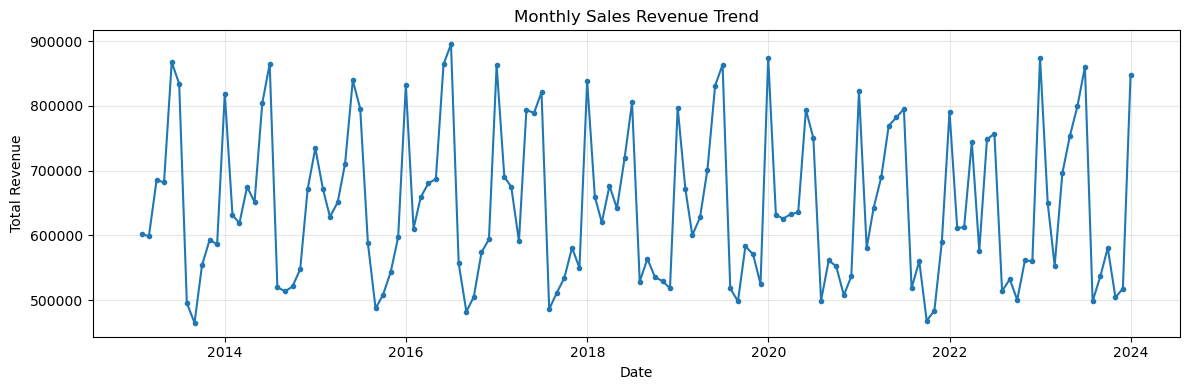

In [36]:
plt.figure(figsize=(12, 4))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    markersize=3
)

plt.title("Monthly Sales Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observations – Monthly Sales Trend

- Monthly sales revenue shows considerable fluctuations throughout the analysis period.
- Several months record revenue above 800,000, while lower-performing months fall below approximately 500,000.
- There is no clear continuous upward or downward trend across the entire period; instead, sales repeatedly rise and fall from month to month.
- The recurring fluctuations suggest that sales performance may be influenced by seasonal demand or changes in purchasing activity.
- Further quarterly analysis can help smooth short-term monthly variations and provide a clearer view of broader sales patterns.

### Quarterly Sales Trend

Quarterly revenue is analyzed to reduce short-term monthly fluctuations and identify broader sales patterns over time.

In [39]:
quarterly_sales = (
    df.set_index("Date")
      .resample("QE")["Revenue"]
      .sum()
)

quarterly_sales.head()

Date
2013-03-31    1885985
2013-06-30    2383934
2013-09-30    1513828
2013-12-31    1998416
2014-03-31    1925047
Freq: QE-DEC, Name: Revenue, dtype: int64

In [40]:
df["Year"] = df["Date"].dt.year
df["Quarter"] = df["Date"].dt.quarter

df[["Date", "Year", "Quarter"]].head()

,Date,Year,Quarter
0,2017-11-26,2017,4
1,2014-11-26,2014,4
2,2019-03-23,2019,1
3,2015-03-23,2015,1
4,2018-05-15,2018,2


In [41]:
print("Highest revenue quarter:")
print(quarterly_sales.idxmax(), quarterly_sales.max())

print("\nLowest revenue quarter:")
print(quarterly_sales.idxmin(), quarterly_sales.min())

Highest revenue quarter:
2016-06-30 00:00:00 2446826

Lowest revenue quarter:
2013-09-30 00:00:00 1513828


In [42]:
df["Year_Quarter"] = (
    df["Year"].astype(str) + "-Q" +
    df["Quarter"].astype(str)
)

df[["Date", "Year_Quarter"]].head()

,Date,Year_Quarter
0,2017-11-26,2017-Q4
1,2014-11-26,2014-Q4
2,2019-03-23,2019-Q1
3,2015-03-23,2015-Q1
4,2018-05-15,2018-Q2


In [43]:
quarterly_sales = (
    df.groupby(["Year", "Quarter"], as_index=False)["Revenue"]
      .sum()
)

quarterly_sales["Year_Quarter"] = (
    quarterly_sales["Year"].astype(str) + "-Q" +
    quarterly_sales["Quarter"].astype(str)
)

quarterly_sales.head(20)

,Year,Quarter,Revenue,Year_Quarter
0,2013,1,1885985,2013-Q1
1,2013,2,2383934,2013-Q2
2,2013,3,1513828,2013-Q3
3,2013,4,1998416,2013-Q4
4,2014,1,1925047,2014-Q1
5,2014,2,2320556,2014-Q2
6,2014,3,1554491,2014-Q3
7,2014,4,1953778,2014-Q4
8,2015,1,1950856,2015-Q1
9,2015,2,2346209,2015-Q2


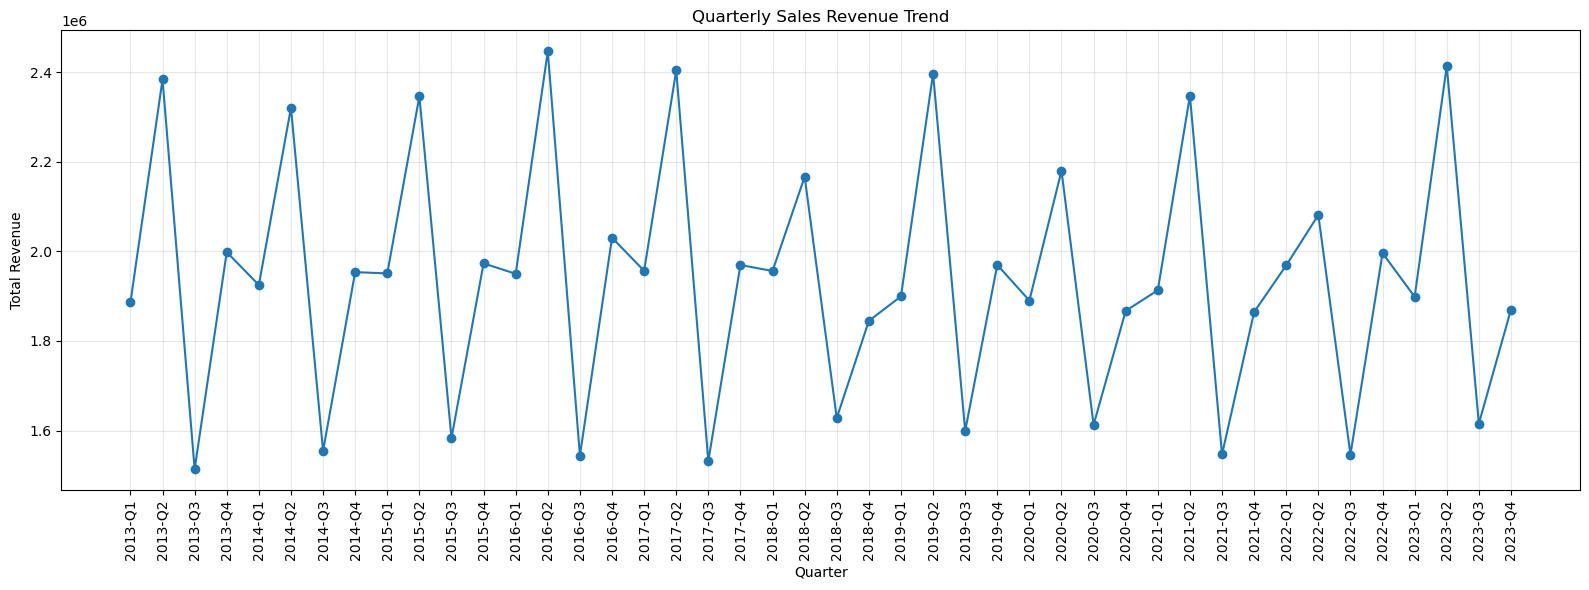

In [44]:
plt.figure(figsize=(16, 6))

plt.plot(
    quarterly_sales["Year_Quarter"],
    quarterly_sales["Revenue"],
    marker="o"
)

plt.title("Quarterly Sales Revenue Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Revenue")

plt.xticks(rotation=90)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observations – Quarterly Sales Trend

- Quarterly revenue shows a recurring seasonal pattern across the years.
- Q2 is consistently one of the strongest-performing quarters, with several years recording revenue above 2.3 million.
- Q3 is generally the weakest-performing quarter, with revenue frequently falling to around 1.5–1.6 million.
- The highest quarterly peaks are visible around Q2 of several years, indicating stronger sales activity during the April–June period.
- The repeated Q2 peaks and Q3 declines suggest a seasonal sales pattern that can be useful for inventory planning, promotions, and resource allocation.

In [46]:
print(df["Age_Group"].value_counts())

Age_Group
Adults (35-64)          55836
Young Adults (25-34)    38666
Youth (<25)             17829
Seniors (64+)             730
Name: count, dtype: int64


In [47]:
print(df["Customer_Gender"].value_counts())

Customer_Gender
M    58326
F    54735
Name: count, dtype: int64


## Customer Demographics Analysis

Customer demographics are analyzed to understand the composition of the customer base based on age groups and gender.

In [49]:
age_order = [
    "Youth (<25)",
    "Young Adults (25-34)",
    "Adults (35-64)",
    "Seniors (64+)"
]

age_counts = (
    df["Age_Group"]
    .value_counts()
    .reindex(age_order)
)

age_counts

Age_Group
Youth (<25)             17829
Young Adults (25-34)    38666
Adults (35-64)          55836
Seniors (64+)             730
Name: count, dtype: int64

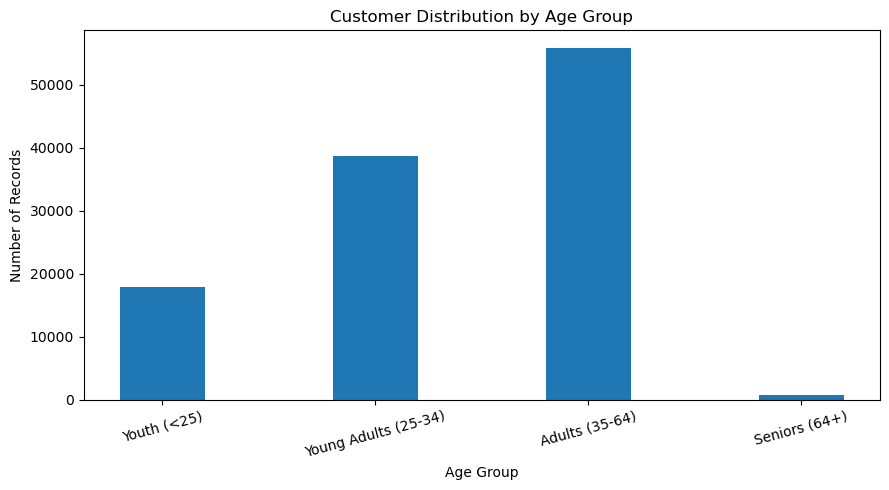

In [50]:
plt.figure(figsize=(9, 5))

plt.bar(age_counts.index, age_counts.values, width=0.4)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Records")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Observations – Customer Age Groups

- Adults aged 35–64 represent the largest customer segment, with 55,836 records.
- Young Adults aged 25–34 form the second-largest segment, with 38,666 records.
- Customers below 25 account for a smaller portion of the dataset, while customers aged 64+ represent a very small segment.
- The results indicate that the business primarily serves adult and young-adult customers, making these groups important target segments for marketing and product strategies.

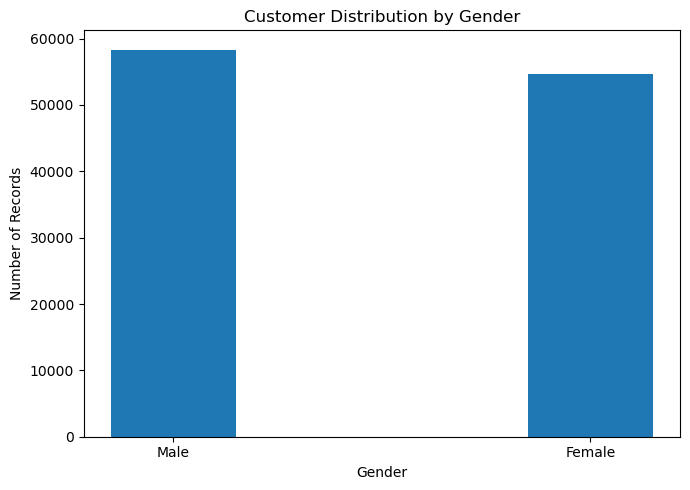

In [52]:
gender_counts = df["Customer_Gender"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(gender_counts.index, gender_counts.values, width=0.3)
,
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Records")

plt.xticks(
    ticks=[0, 1],
    labels=["Male", "Female"]
)

plt.tight_layout()
plt.show()

## Product Analysis

Product analysis is performed to identify the best-selling products based on total quantity sold and to understand the contribution of different product categories to overall revenue.

In [54]:
top_10_products = (
    df.groupby("Product")["Order_Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_10_products

Product
Water Bottle - 30 oz.      164134
Patch Kit/8 Patches        157614
Mountain Tire Tube         102792
AWC Logo Cap                67334
Sport-100 Helmet, Red       63691
Road Tire Tube              62296
Sport-100 Helmet, Black     62131
Fender Set - Mountain       62118
Touring Tire Tube           56802
Sport-100 Helmet, Blue      55895
Name: Order_Quantity, dtype: int64

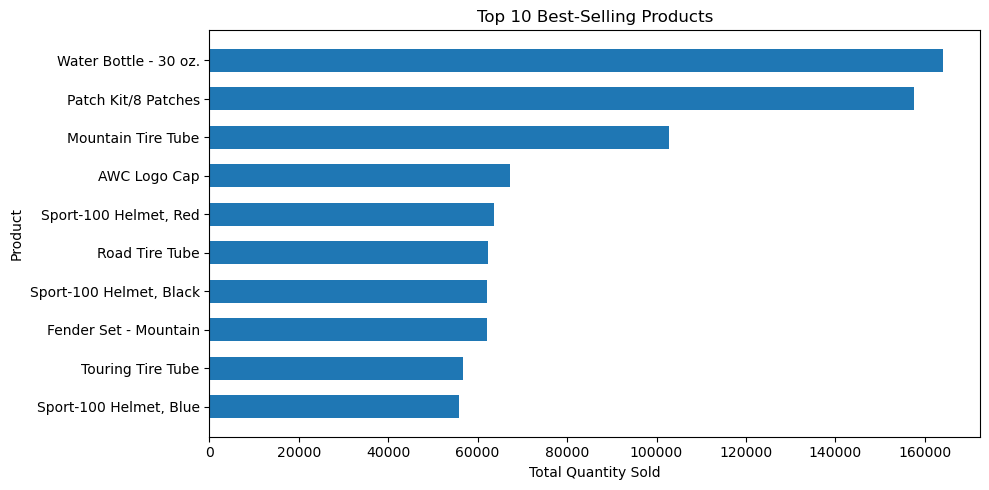

In [55]:
plt.figure(figsize=(10, 5))

plt.barh(
    top_10_products.index,
    top_10_products.values,
    height=0.6
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Observations – Top 10 Best-Selling Products

- **Water Bottle - 30 oz.** is the best-selling product based on total quantity sold.
- **Patch Kit/8 Patches** is the second-highest-selling product, followed by **Mountain Tire Tube**.
- The top-selling list is dominated by cycling accessories and maintenance-related products such as water bottles, patch kits, tire tubes, helmets, and fender sets.
- The significant demand for accessories and maintenance products suggests that these items are frequently purchased and should receive adequate inventory attention.

In [57]:
category_revenue = (
    df.groupby("Product_Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

category_revenue

Product_Category
Bikes          61802247
Accessories    15119947
Clothing        8376004
Name: Revenue, dtype: int64

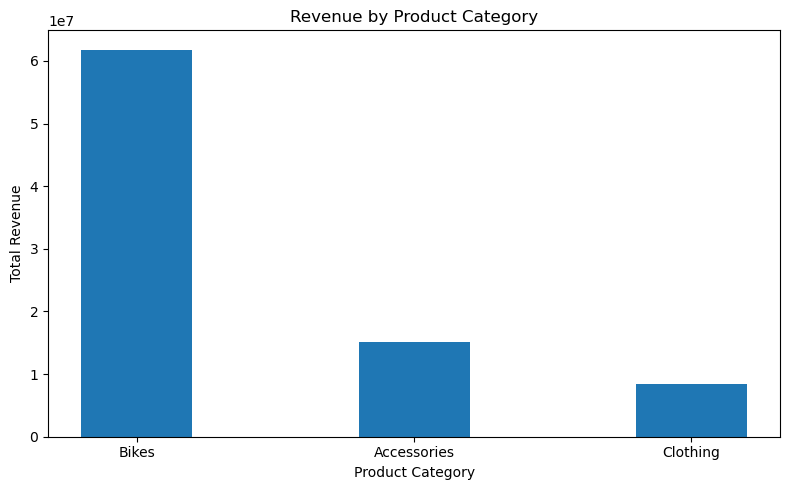

In [58]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_revenue.index,
    category_revenue.values,
    width=0.4
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

## Correlation Analysis

Correlation analysis is performed to examine the strength and direction of relationships between important numerical variables in the retail sales dataset.

In [60]:
correlation_columns = [
    "Customer_Age",
    "Order_Quantity",
    "Unit_Cost",
    "Unit_Price",
    "Profit",
    "Cost",
    "Revenue",
    "Rating"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix.round(2)

,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue,Rating
Customer_Age,1.00,0.03,-0.02,-0.02,0.00,-0.02,-0.01,-0.00
Order_Quantity,0.03,1.00,-0.52,-0.52,-0.24,-0.34,-0.31,0.01
Unit_Cost,-0.02,-0.52,1.00,1.00,0.74,0.83,0.82,-0.00
Unit_Price,-0.02,-0.52,1.00,1.00,0.75,0.83,0.82,-0.00
Profit,0.00,-0.24,0.74,0.75,1.00,0.90,0.96,-0.00
Cost,-0.02,-0.34,0.83,0.83,0.90,1.00,0.99,-0.00
Revenue,-0.01,-0.31,0.82,0.82,0.96,0.99,1.00,-0.00
Rating,-0.00,0.01,-0.00,-0.00,-0.00,-0.00,-0.00,1.00


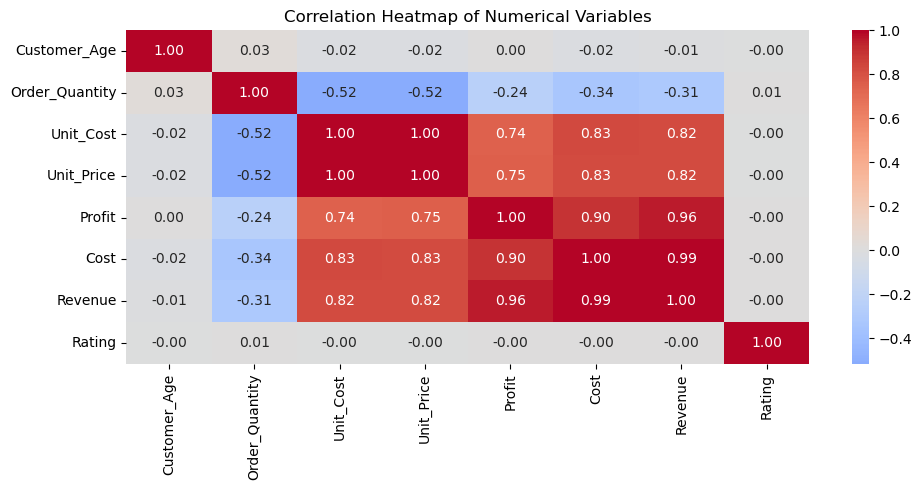

In [61]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()
plt.show()

### Observations – Correlation Analysis

- `Unit_Cost` and `Unit_Price` show an almost perfect positive correlation (1.00), indicating that higher-cost products are generally sold at proportionally higher prices.
- `Revenue` and `Cost` have a very strong positive relationship (approximately 0.99), showing that higher-revenue transactions are also associated with higher total costs.
- `Profit` is strongly positively correlated with `Revenue` (approximately 0.96) and `Cost` (approximately 0.90).
- `Order_Quantity` has a moderate negative correlation with `Unit_Cost` and `Unit_Price` (approximately -0.52). This suggests that lower-priced products tend to be purchased in larger quantities.
- `Customer_Age` shows almost no correlation with the major financial variables, suggesting that age alone does not strongly determine transaction value.
- `Rating` also shows very weak correlations with the other numerical variables, indicating that customer ratings are not strongly associated with price, revenue, quantity, or profitability in this dataset.

In [63]:
age_performance = (
    df.groupby("Age_Group")[["Revenue", "Profit"]]
      .sum()
      .reindex(age_order)
)

age_performance

,Revenue,Profit
Age_Group,,
Youth (<25),11723905,4374986
Young Adults (25-34),30664262,11389700
Adults (35-64),42601989,16327100
Seniors (64+),308042,138165


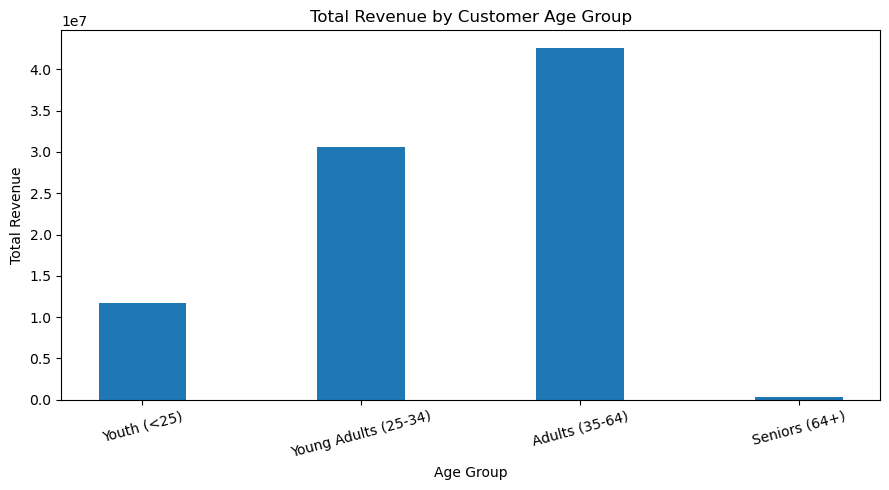

In [64]:
plt.figure(figsize=(9, 5))

plt.bar(
    age_performance.index,
    age_performance["Revenue"],
    width=0.4
)

plt.title("Total Revenue by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Revenue")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Observations – Revenue by Age Group

- Adults aged 35–64 generate the highest total revenue among all customer age groups.
- Young Adults aged 25–34 are the second-largest contributors to overall revenue.
- Youth customers below 25 contribute a smaller share of total revenue.
- Seniors aged 64+ contribute only a very small portion of overall revenue.
- The revenue pattern broadly follows the customer distribution, indicating that Adults and Young Adults are the most commercially significant customer segments.
- These findings suggest that marketing and promotional strategies can prioritize Adults and Young Adults while exploring opportunities to improve engagement among the smaller age segments.

In [66]:
category_profit = (
    df.groupby("Product_Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit

Product_Category
Bikes          20525500
Accessories     8863503
Clothing        2840948
Name: Profit, dtype: int64

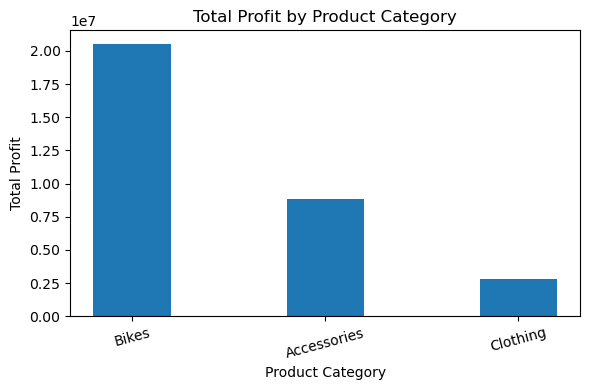

In [67]:
plt.figure(figsize=(6, 4))

plt.bar(
    category_profit.index,
    category_profit.values,
    width=0.4
)

plt.title("Total Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Observations – Profit by Product Category

- Bikes generate the highest total profit among all product categories, making them the most important category from a profitability perspective.
- Accessories are the second-largest contributor to total profit.
- Clothing contributes substantially less profit compared with Bikes and Accessories.
- Although accessories include several of the highest-selling products by quantity, Bikes generate much greater overall profit. This indicates that high sales volume does not necessarily translate into the highest total profitability.
- The business should therefore consider both sales volume and profitability when making inventory, pricing, and promotional decisions.

## Business Recommendations

Based on the findings from the exploratory data analysis, the following recommendations are proposed:

1. **Maintain adequate inventory of high-demand products**  
   Products such as Water Bottle - 30 oz., Patch Kit/8 Patches, and Mountain Tire Tube show high sales volumes. Maintaining sufficient stock of these products can help prevent stockouts and lost sales opportunities.

2. **Focus on Bikes for profitability**  
   Bikes generate substantially higher total profit than Accessories and Clothing. The business should prioritize profitable bike products while optimizing pricing, inventory, and promotional strategies around this category.

3. **Prepare for higher demand during Q2**  
   Quarterly sales analysis shows that Q2 frequently performs strongly. Inventory levels and promotional campaigns should therefore be planned in advance to take advantage of higher demand during this period.

4. **Improve sales performance during Q3**  
   Q3 frequently records lower revenue compared with other quarters. Targeted discounts, seasonal campaigns, product bundles, and special offers can be considered to stimulate demand during this weaker period.

5. **Target the most commercially important age segments**  
   Adults aged 35–64 generate the highest total revenue, followed by Young Adults aged 25–34. Marketing campaigns can prioritize these segments while exploring strategies to increase engagement among Youth and Senior customers.

6. **Balance sales volume with profitability**  
   Accessories dominate several positions among the best-selling products by quantity, while Bikes generate substantially higher total profit. Business decisions should therefore consider both product demand and profitability rather than sales volume alone.

## Conclusion

The Exploratory Data Analysis of the retail sales dataset provided meaningful insights into sales trends, customer demographics, product performance, and profitability.

The analysis revealed noticeable monthly sales fluctuations and a recurring quarterly pattern, with Q2 generally showing stronger performance and Q3 frequently showing weaker performance. Adults aged 35–64 represent the largest customer segment and also contribute the highest total revenue.

Product analysis showed that Water Bottle - 30 oz. is the best-selling product by quantity, while several accessories and maintenance products appear among the top-selling items. However, Bikes generate the highest total profit, demonstrating that high sales volume does not necessarily result in the highest profitability.

Correlation analysis identified strong relationships among Unit Cost, Unit Price, Revenue, Cost, and Profit, while Customer Age and Rating showed relatively weak relationships with the major financial variables.

Overall, the analysis provides actionable insights that can support inventory planning, seasonal promotions, customer targeting, product strategy, and profitability-focused business decisions.

In [71]:
df.to_csv(
    r"C:\Desktop\OIBSIP\DataAnalytics_L1_EDARetailSales\Dataset\cleaned_bike_sales.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
